------------------------------
DAG 数量统计:
------------------------------
节点数 = 5 的 DAG 数量: 8
节点数 = 10 的 DAG 数量: 11
节点数 = 15 的 DAG 数量: 5
节点数 = 20 的 DAG 数量: 36

>>> 正在绘制节点数为 5 的 DAG (展示 8 个)...


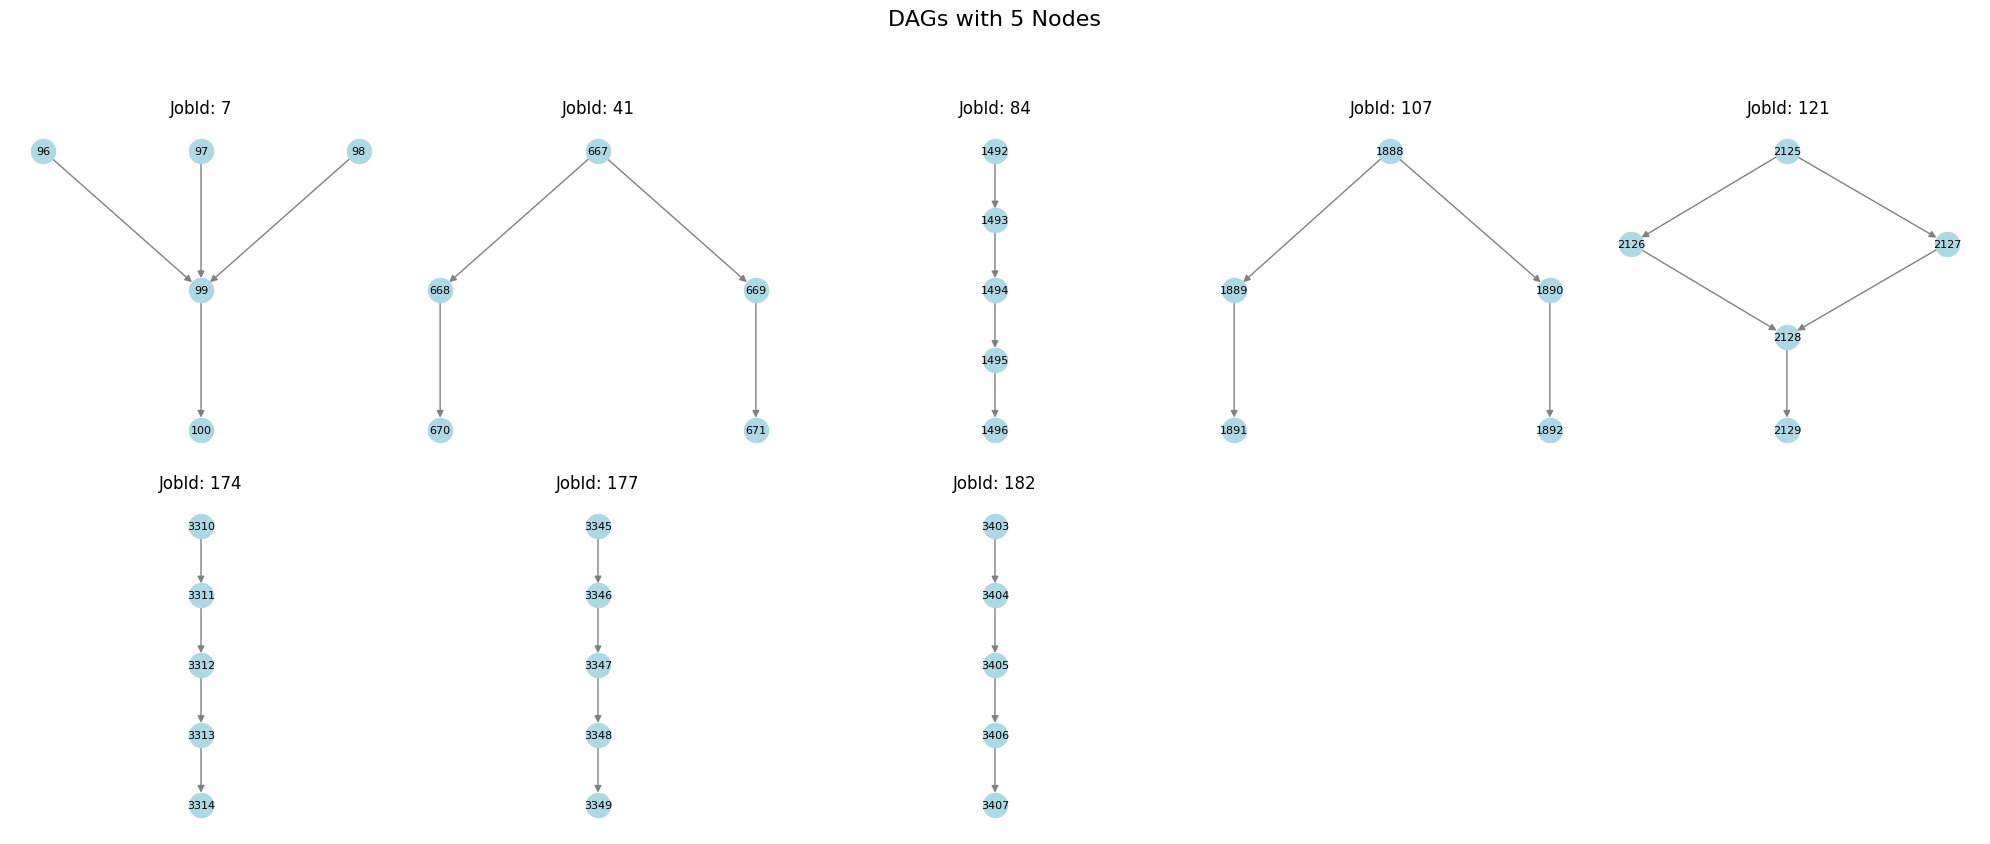


>>> 正在绘制节点数为 10 的 DAG (展示 10 个)...


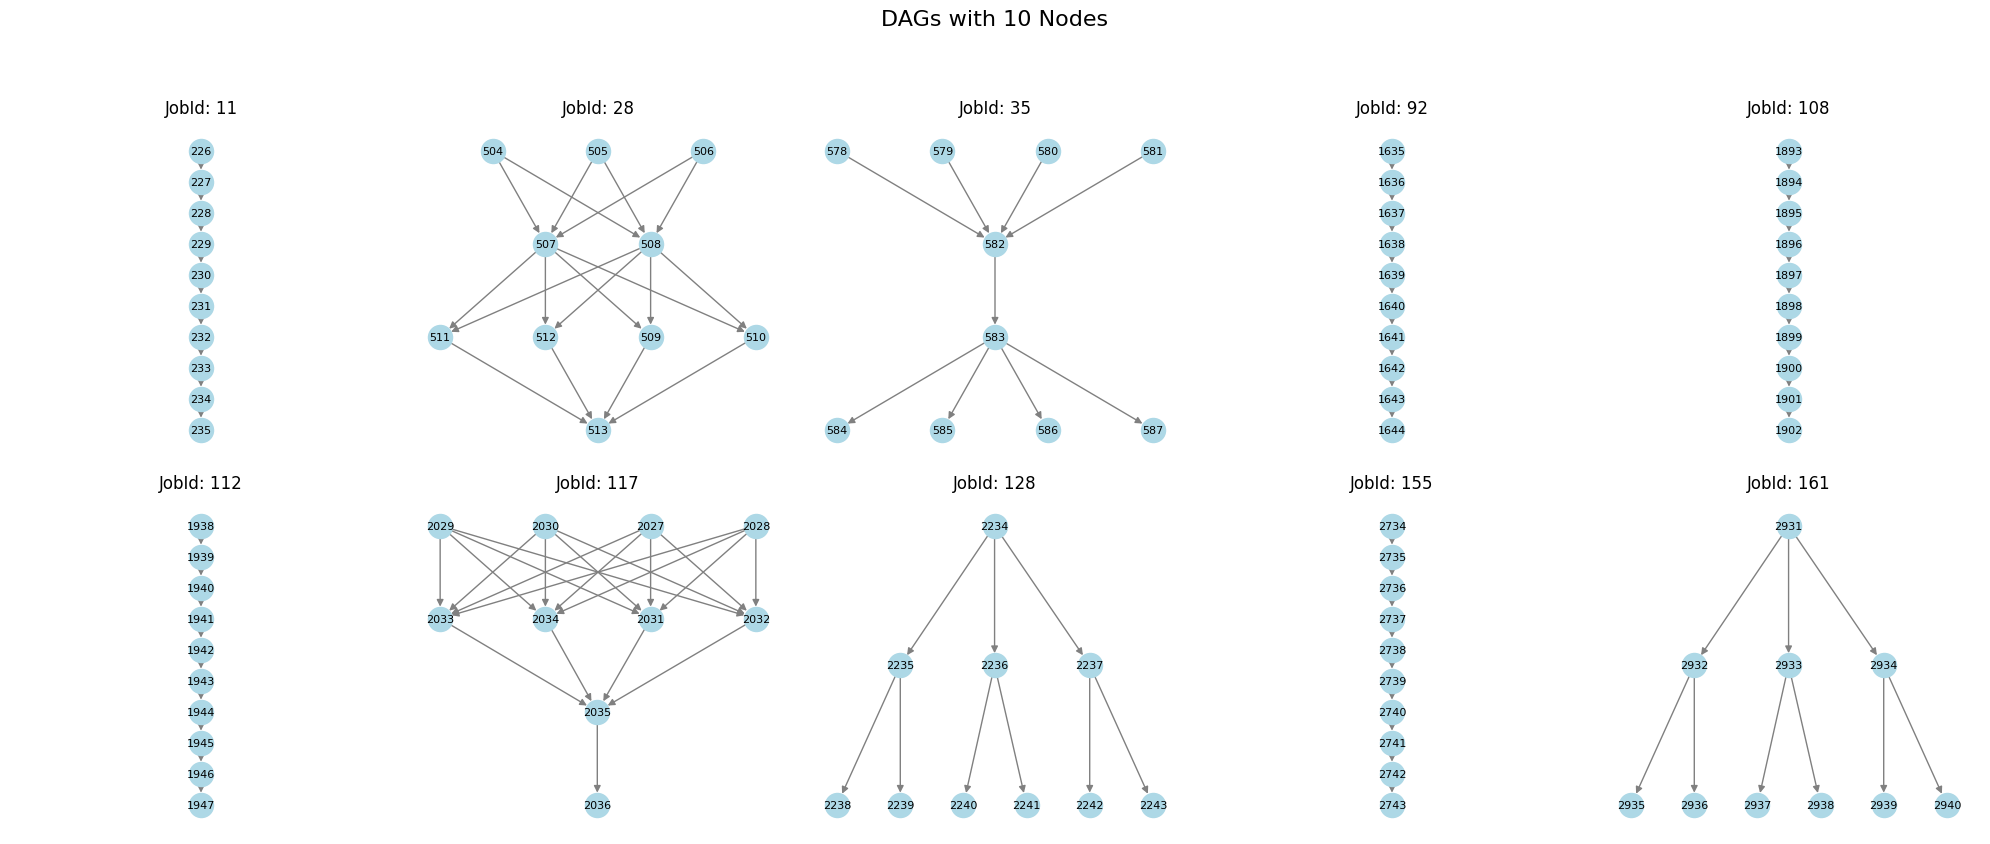


>>> 正在绘制节点数为 15 的 DAG (展示 5 个)...


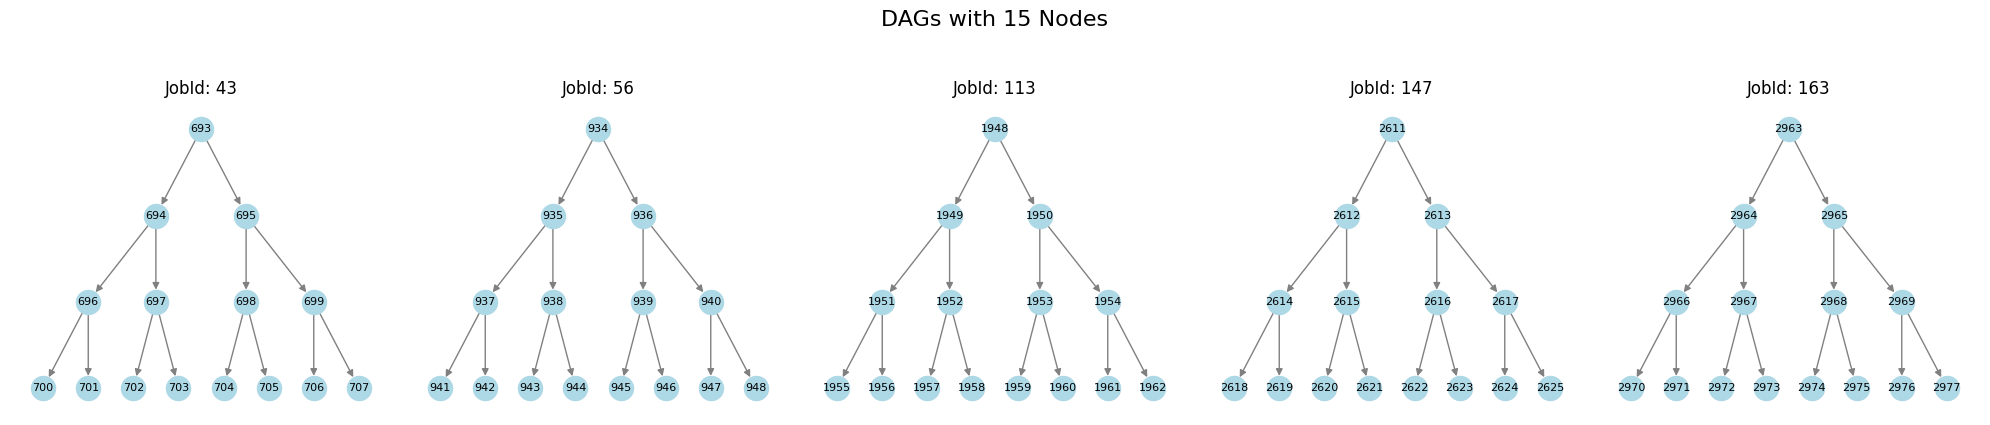


>>> 正在绘制节点数为 20 的 DAG (展示 10 个)...


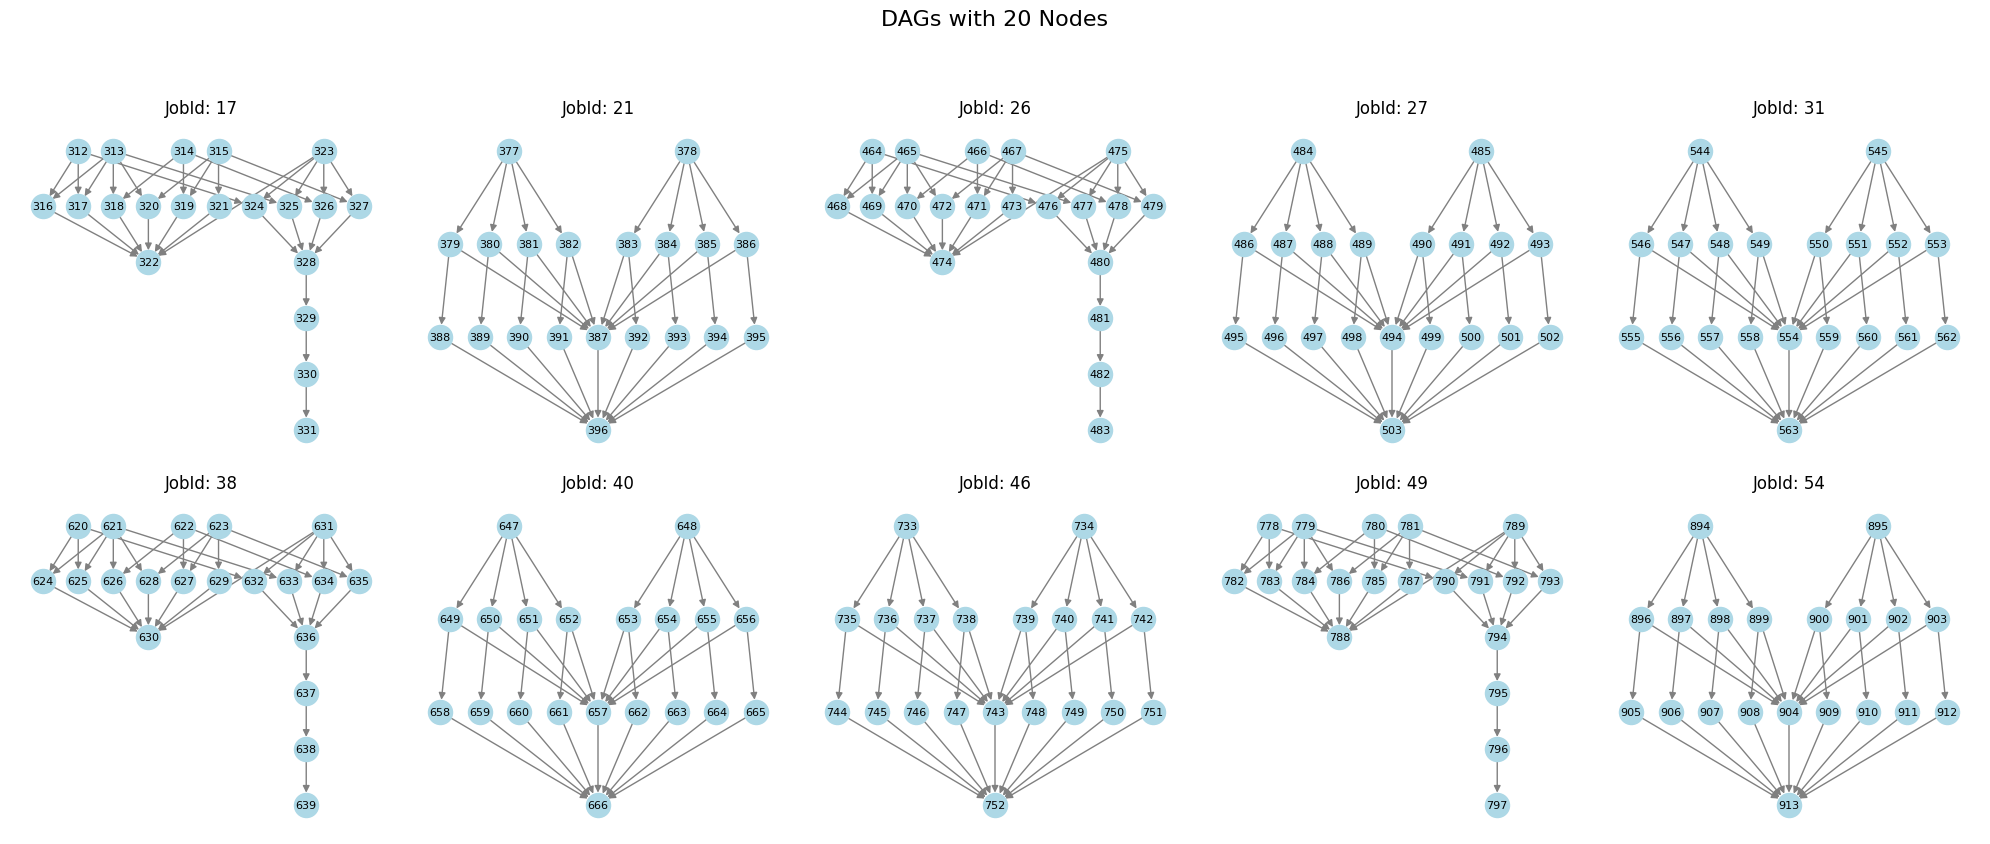

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ast

# 1. 读取数据
df = pd.read_csv("task_table.csv")

# 2. 统计数量
# 按 JobId 分组并计算每个 Job 的任务数量
job_sizes = df.groupby("JobId").size()
target_sizes = [5, 10, 15, 20]

print("-" * 30)
print("DAG 数量统计:")
print("-" * 30)

for size in target_sizes:
    count = (job_sizes == size).sum()
    print(f"节点数 = {size} 的 DAG 数量: {count}")


# 3. 定义构建 DAG 的函数
def build_dag_from_df(job_df):
    G = nx.DiGraph()
    # 添加节点
    for _, row in job_df.iterrows():
        G.add_node(row["TaskId"])

    # 添加边 (解析 ParentTasks 字段)
    for _, row in job_df.iterrows():
        child_id = row["TaskId"]
        parents_str = row["ParentTasks"]

        if pd.notna(parents_str) and parents_str != "[]":
            try:
                # 字符串格式如 "[[0, 9], [1, 5]]"，解析为列表
                parents = ast.literal_eval(parents_str)
                for p in parents:
                    parent_id = int(p[0])
                    # p[1] 是通信开销，如果需要可以作为权重添加
                    G.add_edge(parent_id, child_id)
            except Exception as e:
                pass
    return G


# 4. 遍历并画图
for size in target_sizes:
    # 获取符合当前节点数的 JobId 列表
    job_ids = job_sizes[job_sizes == size].index.tolist()

    if not job_ids:
        print(f"\n没有找到节点数为 {size} 的 DAG。")
        continue

    # 取前10个 (如果不足10个则取全部)
    selected_jobs = job_ids[:10]

    print(f"\n>>> 正在绘制节点数为 {size} 的 DAG (展示 {len(selected_jobs)} 个)...")

    # 设置画布布局 (每行5个)
    cols = 5
    rows = (len(selected_jobs) + cols - 1) // cols
    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle(f"DAGs with {size} Nodes", fontsize=16, y=1.05)

    for i, job_id in enumerate(selected_jobs):
        # 提取该 Job 的所有任务数据
        job_df = df[df["JobId"] == job_id]

        # 构建图
        G = build_dag_from_df(job_df)

        ax = plt.subplot(rows, cols, i + 1)

        # 布局算法：优先使用 graphviz (层级清晰)，如果没有则使用 spring
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
        except:
            pos = nx.spring_layout(G, seed=42)

        nx.draw(G, pos, ax=ax, with_labels=True, node_size=300, node_color="lightblue", font_size=8, arrowsize=10, edge_color="gray")
        ax.set_title(f"JobId: {job_id}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()